In [501]:
%matplotlib widget
from importlib import reload
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

import sys
sys.path.append('/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability')
import proba_modules as pm
reload(pm)

<module 'proba_modules' from '/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability/proba_modules.py'>

In [49]:
import surface_ratios_module as srm

lon_0, lat_0 = 0., -89.
opt_maps = dict(
    #folder_TL_data='./data/TL_data/', 
    lat_0=lat_0, 
    lon_0=lon_0, 
    R0=R0
)
polygon_map = srm.compute_map(**opt_maps)

PATH_VENUS_DATA = os.path.join("./Venus_Detectability/data/")
find_active_corona_only=True
l_unioned_linestring = srm.load_tectonic_iris_shp(PATH_VENUS_DATA, polygon_map, epsilon=1e-1, lat_0=-89., lon_0=0., R0=6052000, find_active_corona_only=find_active_corona_only)

Processing corona
Split linestrings crossing antimeridian


/staff/quentin/miniconda2/envs/seismonpy/lib/python3.7/site-packages/geopandas/geoseries.py:844: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if s.type.startswith("Multi") or s.type == "GeometryCollection":
/staff/quentin/miniconda2/envs/seismonpy/lib/python3.7/site-packages/geopandas/geodataframe.py:1322: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super(GeoDataFrame, self).__setitem__(key, value)
/staff/quentin/miniconda2/envs/seismonpy/lib/python3.7/site-packages/geopandas/geoseries.py:844: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if s.t

Buffering linestrings into polygons
Trim polygons with values beyond -180, 180
Project polygons to 2d map


/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability/surface_ratios_module.py:258: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  wrinkle_ridges['geometry'] = wrinkle_ridges.geometry.buffer(epsilon)


Converting list of polygons into multipolygon
Processing rift
Split linestrings crossing antimeridian


...

Buffering linestrings into polygons
Trim polygons with values beyond -180, 180
Project polygons to 2d map
Converting list of polygons into multipolygon
Processing ridge
Split linestrings crossing antimeridian


/staff/quentin/miniconda2/envs/seismonpy/lib/python3.7/site-packages/geopandas/geoseries.py:844: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if s.type.startswith("Multi") or s.type == "GeometryCollection":
/staff/quentin/miniconda2/envs/seismonpy/lib/python3.7/site-packages/geopandas/geodataframe.py:1322: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super(GeoDataFrame, self).__setitem__(key, value)
/staff/quentin/miniconda2/envs/seismonpy/lib/python3.7/site-packages/geopandas/geodataframe.py:1322: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead



Buffering linestrings into polygons
Trim polygons with values beyond -180, 180
Project polygons to 2d map
Converting list of polygons into multipolygon
Split linestrings crossing antimeridian


/staff/quentin/miniconda2/envs/seismonpy/lib/python3.7/site-packages/geopandas/geoseries.py:844: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if s.type.startswith("Multi") or s.type == "GeometryCollection":
/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability/surface_ratios_module.py:258: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  wrinkle_ridges['geometry'] = wrinkle_ridges.geometry.buffer(epsilon)


Buffering linestrings into polygons
Trim polygons with values beyond -180, 180
Project polygons to 2d map
Converting list of polygons into multipolygon


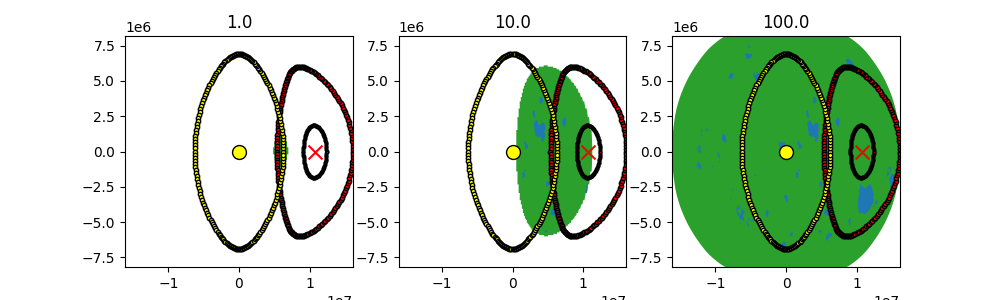

In [61]:
from matplotlib.patches import Polygon as Polygon_mpl
import pyproj
import compute_network_shapes_CPUs as cns
import geopandas as gpd

def circle_coords(x0, y0, R, N=100):
    theta = np.linspace(0, 2*np.pi, N, endpoint=False)
    x = x0 + R * np.cos(theta)
    y = y0 + R * np.sin(theta)
    return x, y

folder_shp = 'airglow_shp'
model = 'Cold100'
SNR = 150.
type_airglow = 'dayglow'
ext = 'gpkg'
iscenario = 60
lon_0_airglow=dict(nightglow=180., dayglow=0.)
radius_airglow=dict(nightglow=60., dayglow=70.)
radius_view=60.
distance = 2010.

type_instruments = f'{type_airglow}_SNRnight{SNR:.1f}_SNRday{SNR:.1f}_same_event'
network = f'{type_instruments}_m{model}_12.12.2025'
file_shp = f'./data/{folder_shp}/{network}.{ext}'
gdf = gpd.read_file(file_shp)
    
dlon_stations = 5.
lats, lons = np.arange(-90, 89, dlon_stations/2.), np.arange(-180, 179, dlon_stations)
offsets = []
dict_stations = dict(offsets=offsets, use_airglow=True, use_only_airglow=True, fixed_stations=dict(), add_velocity=True, vel_baloon=0.1, vel_imager=0.33)
lats_stations, lons_stations, id_scenario, id_stat = cns.get_stations(lats, lons, **dict_stations)

R0=6052000
proj = pyproj.Proj(proj='robin', lat_0=0., lon_0=0., a=R0, b=R0)
fig = plt.figure(figsize=(10,3))
grid = fig.add_gridspec(1, 3)

cpt = -1
for period, gdf_polys_processed in gdf.loc[(gdf.iscenario==iscenario)&(gdf['distance']==distance)].groupby('period'):

    polys_processed = gdf_polys_processed.geometry.iloc[0]
    
    cpt += 1
    ax = fig.add_subplot(grid[0,cpt],)
    
    if polys_processed.geom_type == 'MultiPolygon':
        polys_loc = polys_processed.geoms
    else:
        polys_loc = [polys_processed]

    region = l_unioned_linestring['corona']
    for poly in polys_loc:
        coords = np.array(poly.exterior.coords)
        p = Polygon_mpl(coords, facecolor = 'tab:green')
        ax.add_patch(p)
        for interior in poly.interiors:
            interior_coords = np.array(interior.coords)
            interior_patch = Polygon_mpl(interior_coords, facecolor='white')  # Set hole facecolor to white
            ax.add_patch(interior_patch)
    
        for interior in region.geoms:
            intersection = interior.intersection(poly)
            if intersection.geom_type == 'MultiPolygon':
                polys_loc_v2 = intersection.geoms
            else:
                polys_loc_v2 = [intersection]
            for interior_2 in polys_loc_v2:
                coords = np.array(interior_2.exterior.coords)
                p = Polygon_mpl(coords, facecolor = 'tab:blue')
                ax.add_patch(p)
    
    x, y = proj(lons_stations[iscenario, :], lats_stations[iscenario, :])
    ax.scatter(x, y, marker='x', s=100, color='red')
    x, y = circle_coords(x0=lons_stations[iscenario, :], y0=lats_stations[iscenario, :], R=radius_view, N=200)
    x, y = proj(x, y)
    ax.scatter(x, y, marker='o', s=10, color='red', edgecolor='black')
    x, y = circle_coords(x0=lons_stations[iscenario, :], y0=lats_stations[iscenario, :], R=distance/110., N=200)
    x, y = proj(x, y)
    ax.scatter(x, y, marker='o', s=3, color='red', edgecolor='black')
    
    x, y = proj(lon_0_airglow[type_airglow], 0.)
    ax.scatter(x, y, marker='o', s=100, color='yellow', edgecolor='black')
    x, y = circle_coords(x0=lon_0_airglow[type_airglow], y0=0., R=radius_airglow[type_airglow], N=200)
    x, y = proj(x, y)
    ax.scatter(x, y, marker='o', s=10, color='yellow', edgecolor='black')

    ax.set_title(period)
    
    xmin, _ = proj(-180., 0.)
    xmax, _ = proj(180., 0.)
    _, ymin = proj(0., -90.)
    _, ymax = proj(0., 90.)
    ax.set_xlim([xmin, xmax])
    ax.set_ylim([ymin, ymax])

100%|██████████| 3/3 [00:00<00:00,  4.73it/s]


Dayglow period 1.0
Dayglow period 10.0
Dayglow period 100.0
Nightglow period 1.0
Nightglow period 10.0
Nightglow period 100.0


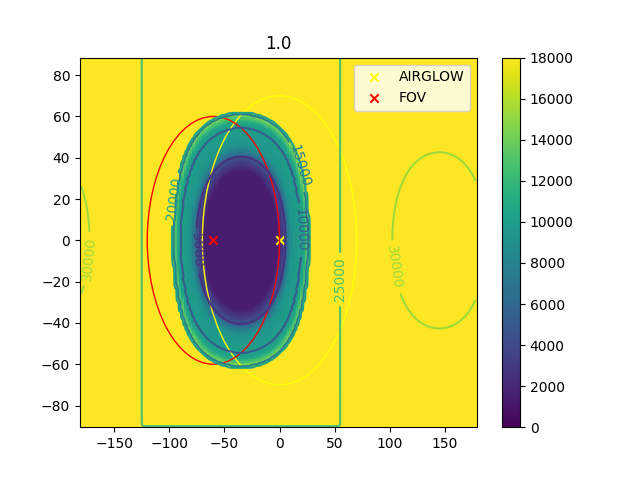

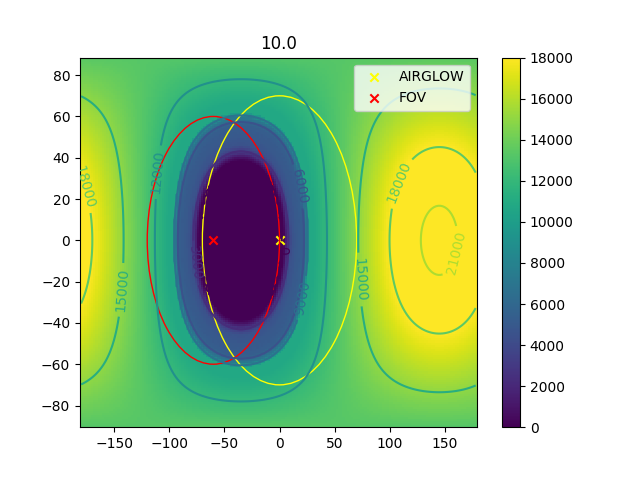

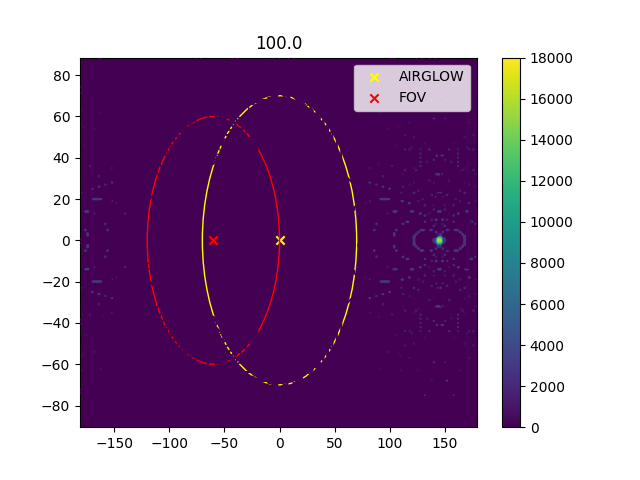

In [479]:
import sys
sys.path.append('./Venus_Detectability/')
import compute_network_shapes_CPUs as cns

def haversine_distance(lon1, lat1, lons, lats, RADIUS_VENUS=6051.8e3):
    """
    Vectorized Haversine formula to compute distances on Venus.

    lon1, lat1 : scalar
        Reference longitude and latitude in degrees.
    lons, lats : arrays
        Arrays of longitudes and latitudes in degrees.

    Returns
    -------
    distances : array
        Array of distances from (lon1, lat1) to each point in (lons, lats) in meters.
    """
    # Convert degrees to radians
    lon1_rad = np.radians(lon1)
    lat1_rad = np.radians(lat1)
    lons_rad = np.radians(lons)
    lats_rad = np.radians(lats)
    
    # Haversine formula
    dlon = lons_rad - lon1_rad
    dlat = lats_rad - lat1_rad
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1_rad) * np.cos(lats_rad) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    # Distance in meters
    distances = RADIUS_VENUS * c
    
    return distances

def compute_intersections(C1, L1, C2_in, L2, type_airglow='dayglow'):
    """
    Compute the intersection center and half-length for multiple cases.

    Parameters:
    C1, L1 : ndarray
        Centers and half-lengths of the first set of lines.
    C2, L2 : ndarray
        Centers and half-lengths of the second set of lines.

    Returns:
    intersection_centers : ndarray
        Centers of the intersections.
    intersection_half_lengths : ndarray
        Half-lengths of the intersections.
    """

    C2 = C2_in.copy()
    if type_airglow == 'nightglow':
        C1 = C1 if C1 > 0 else C1 + 360.
        C2[C2<0] += 360.
    
    # Calculate endpoints for both sets of lines
    start1, end1 = C1 - L1, C1 + L1
    start2, end2 = C2 - L2, C2 + L2

    # Intersection endpoints
    left = np.maximum(start1, start2)
    right = np.minimum(end1, end2)

    # Check for intersections and compute results
    valid = left <= right  # Boolean mask for valid intersections
    intersection_centers = np.where(valid, (left + right) / 2, 0.)
    intersection_half_lengths = np.where(valid, (right - left) / 2, -1.)

    intersection_centers[intersection_centers>180.] -= 360.

    return intersection_centers, intersection_half_lengths

type_airglow = 'dayglow'
boost_SNR = dict(dayglow=1., nightglow=1.)
boost_SNR = dict(dayglow=25., nightglow=25.)
periods = [1., 10., 100.]
model_subsurface = 'Cold100'
alt_scaling_airglow = 0.
alt_ref_balloon = 90.
main_dir = '/staff/quentin/Documents/Projects/2024_Venus_Detectability/'
dir_GF = '/projects/restricted/infrasound/data/infrasound/2023_Venus_inversion/'
file_curve = f'{dir_GF}GF_Dirac_1Hz_combined_wHot40_lognormal_updated_minthick.csv'
file_precomputed_scaling = f'{main_dir}data/scaling_airglow/data_airglow_scaling_freqscaled.csv'
dict_scaling = dict(file_precomputed_scaling=file_precomputed_scaling, R0=6052000, sigma_balloon=1e-2, boost_SNR=boost_SNR, photons_dayglow=3.5e5, alpha_dayglow=1e-5, photons_nightglow=2e4, beta=1., file_atmos=f'{main_dir}Venus_Detectability/data/profile_VCD_for_scaling_pd.csv', file_nightglow=f'{main_dir}Venus_Detectability/data/VER_profile_scaled.csv', file_dayglow=f'{main_dir}Venus_Detectability/data/VER_profile_dayglow.csv', model_subsurface=model_subsurface, alt_scaling_airglow=alt_scaling_airglow, alt_ref_balloon=alt_ref_balloon)
freq = [1e-2, 1e-1, 1.]
f_alt_scaling_dayglow, f_alt_scaling_nightglow, TL_new_v, TL_new_p = cns.get_airglow_scaling(file_curve, freq, **dict_scaling)
f_alt_scaling = f_alt_scaling_dayglow if type_airglow == 'dayglow' else f_alt_scaling_nightglow

lon_0_airglow = dict(nightglow=180., dayglow=0.)
radius_airglow = dict(nightglow=60., dayglow=70.)
radius_view = 60.
dlon = 2.
lats, lons = np.arange(-90, 89, dlon/2.), np.arange(-180, 179, dlon)
LATS, LONS, shape_init = cns.get_grid(lats, lons)
lons_stations = lons

new_lon, new_radius = compute_intersections(lon_0_airglow[type_airglow], radius_airglow[type_airglow], lons_stations, radius_view, type_airglow=type_airglow)
max_dist_airglow = haversine_distance(LONS[:,None], LATS[:,None], new_lon[None,:], LONS[:,None]*0.,) 

for period in periods:
    max_dist_airglow -= new_radius[None,:]*1e2*1e3
    max_dist_airglow[max_dist_airglow<0] = 0.
    max_dist_airglow[np.repeat(new_radius[None,:], max_dist_airglow.shape[0], axis=0)<0] = 1e10
    max_dist_airglow += f_alt_scaling[period](max_dist_airglow/1e3)*1e3
    max_dist_airglow[max_dist_airglow<0] = 0.
    #max_dist_airglow[max_dist_airglow/1e3>18500.] = 18500.*1e3
    
    import matplotlib.patches as patches
    
    ii = 60
    plt.figure()
    dists_map = max_dist_airglow[:,ii].reshape(shape_init).T/1e3
    sc = plt.pcolormesh(lons, lats, dists_map, vmin=0., vmax=18000.)
    plt.colorbar(sc)
    ax = plt.gca()
    X, Y = np.meshgrid(lons, lats)
    CS = ax.contour(X, Y, dists_map)
    ax.clabel(CS, fontsize=10)
    plt.scatter(lon_0_airglow[type_airglow], 0., marker='x', color='yellow', label='AIRGLOW')
    plt.scatter(lons[ii], 0., marker='x', color='red', label='FOV')
    ax = plt.gca()
    circle = patches.Circle((lon_0_airglow[type_airglow], 0), radius=radius_airglow[type_airglow], facecolor='none', edgecolor='yellow'); 
    circle_view = patches.Circle((lons[ii], 0), radius=radius_view, facecolor='none', edgecolor='red');
    ax.add_patch(circle);
    ax.add_patch(circle_view);
    plt.legend()
    plt.title(period)

In [421]:
R0 = 6052000
lon_0, lat_0 = 0., -89.
opt_maps = dict(
    lat_0=lat_0, 
    lon_0=lon_0, 
    R0=R0
)
polygon_map = srm.compute_map(**opt_maps)
PATH_VENUS_DATA = os.path.join("./Venus_Detectability/data/")

find_active_corona_only=True
l_unioned_linestring = srm.load_tectonic_iris_shp(PATH_VENUS_DATA, polygon_map, epsilon=1e-1, lat_0=-89., lon_0=0., R0=6052000, find_active_corona_only=find_active_corona_only)

Processing corona
Split linestrings crossing antimeridian


/staff/quentin/miniconda2/envs/seismonpy/lib/python3.7/site-packages/geopandas/geoseries.py:844: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if s.type.startswith("Multi") or s.type == "GeometryCollection":
/staff/quentin/miniconda2/envs/seismonpy/lib/python3.7/site-packages/geopandas/geodataframe.py:1322: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super(GeoDataFrame, self).__setitem__(key, value)
/staff/quentin/miniconda2/envs/seismonpy/lib/python3.7/site-packages/geopandas/geoseries.py:844: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if s.t

Buffering linestrings into polygons
Trim polygons with values beyond -180, 180
Project polygons to 2d map
Converting list of polygons into multipolygon
Processing rift
Split linestrings crossing antimeridian


/staff/quentin/miniconda2/envs/seismonpy/lib/python3.7/site-packages/geopandas/geodataframe.py:1322: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super(GeoDataFrame, self).__setitem__(key, value)
/staff/quentin/miniconda2/envs/seismonpy/lib/python3.7/site-packages/geopandas/geodataframe.py:1322: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super(GeoDataFrame, self).__setitem__(key, value)
/staff/quentin/miniconda2/envs/seismonpy/lib/python3.7/site-packages/geopandas/geodataframe.py:1322: SettingWithCopyWa

Buffering linestrings into polygons
Trim polygons with values beyond -180, 180
Project polygons to 2d map
Converting list of polygons into multipolygon
Processing ridge
Split linestrings crossing antimeridian


/staff/quentin/miniconda2/envs/seismonpy/lib/python3.7/site-packages/geopandas/geoseries.py:844: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if s.type.startswith("Multi") or s.type == "GeometryCollection":
/staff/quentin/miniconda2/envs/seismonpy/lib/python3.7/site-packages/geopandas/geodataframe.py:1322: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super(GeoDataFrame, self).__setitem__(key, value)
/staff/quentin/miniconda2/envs/seismonpy/lib/python3.7/site-packages/geopandas/geodataframe.py:1322: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead



Buffering linestrings into polygons
Trim polygons with values beyond -180, 180
Project polygons to 2d map
Converting list of polygons into multipolygon
Split linestrings crossing antimeridian


/staff/quentin/miniconda2/envs/seismonpy/lib/python3.7/site-packages/geopandas/geoseries.py:844: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if s.type.startswith("Multi") or s.type == "GeometryCollection":
/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability/surface_ratios_module.py:258: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  wrinkle_ridges['geometry'] = wrinkle_ridges.geometry.buffer(epsilon)


Buffering linestrings into polygons
Trim polygons with values beyond -180, 180
Project polygons to 2d map
Converting list of polygons into multipolygon


./data/airglow_shp/dayglow_SNRnight25.0_SNRday25.0_same_event_mCold100_18.12.2025.gpkg


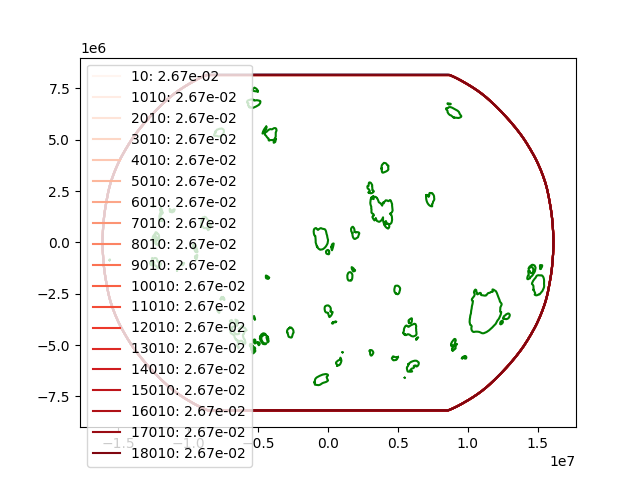

In [472]:
import sys
sys.path.append('./Venus_Detectability/')
import surface_ratios_module as srm

def get_n_colors(cmap_name, n):
    cmap = plt.get_cmap(cmap_name)
    return [cmap(i) for i in np.linspace(0, 1, n)]

folder_shp = 'airglow_shp'
model = 'Cold100'
type_airglow = 'dayglow'
SNR = 25.
period = 100.
ext = 'gpkg'
lon_0_current, lat_0_current = -50., 0.
    
type_instruments = f'{type_airglow}_SNRnight{SNR:.1f}_SNRday{SNR:.1f}_same_event'
network = f'{type_instruments}_m{model}_18.12.2025'
file_shp = f'./data/{folder_shp}/{network}.{ext}'
gdf = gpd.read_file(file_shp)

print(file_shp)

diff_lat = abs(gdf.lon_0-lon_0_current)
diff_lon = abs(gdf.lat_0-lat_0_current)
poly_alldist = gdf.loc[(diff_lat==diff_lat.min())&(diff_lon==diff_lon.min())]

n_radius = 40
colors = get_n_colors("Reds", n_radius//2)

plt.figure(); 
plt.plot(np.array(polygon_map.exterior.coords)[:,0], np.array(polygon_map.exterior.coords)[:,1])

polygon_region = l_unioned_linestring['corona']
for geo in polygon_region.geoms:
    plt.plot(np.array(geo.exterior.coords)[:,0], np.array(geo.exterior.coords)[:,1], color='green')
    
iradius = -1
for radius_target in np.sort(poly_alldist['distance'].unique())[:n_radius:2]:
    iradius += 1
    radius = poly_alldist['distance'].values[np.argmin(abs(poly_alldist['distance'].values-radius_target))]*1e3
    diff_dist = abs(poly_alldist['distance']*1e3-radius)
    poly = poly_alldist.loc[diff_dist==diff_dist.min()]
    diff_t = abs(poly.period-period)
    threshold_acceptable_time = 0.01
    if diff_t.min() > threshold_acceptable_time: ## In case where there is no distance close to radius, i.e., no stations close enough to the source for a network for example we give a zero radius
        continue
    #print(poly)
    poly = poly.loc[diff_t==diff_t.min()]
    poly = poly.geometry.iloc[0]

    intersection = polygon_region.intersection(poly)
    area = intersection.area/polygon_map.area

    label_dict_default = dict(label=f'{radius_target:.0f}: {area:.2e}')
    geo = poly
    if geo.geom_type == 'Polygon':
        plt.plot(np.array(geo.exterior.coords)[:,0], np.array(geo.exterior.coords)[:,1], **label_dict_default, color=colors[iradius])
    elif geo.geom_type == 'MultiPolygon':
        igeo = -1
        for geo in poly.geoms:
            igeo += 1
            label_dict = dict()
            if igeo == 0:
                label_dict = label_dict_default
            plt.plot(np.array(geo.exterior.coords)[:,0], np.array(geo.exterior.coords)[:,1], color=colors[iradius], **label_dict)
#plt.plot(np.array(geo.exterior.coords)[:,0], np.array(geo.exterior.coords)[:,1]) for geo in polygon2.geoms[:1].geoms]
#plt.plot(np.array(polygon_map.exterior.coords)[:,0], np.array(polygon_map.exterior.coords)[:,1]);
plt.legend()

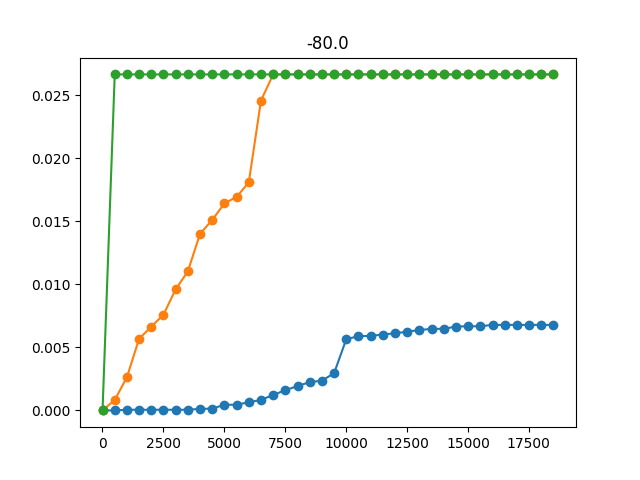

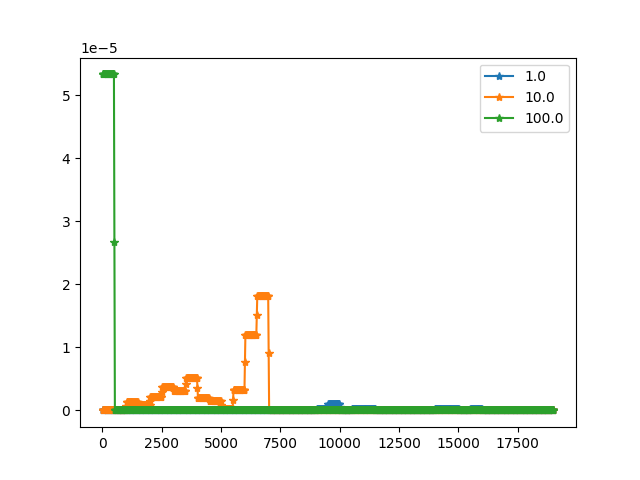

In [486]:
def haversine(lon1, lat1, lon2, lat2, r = 6052.):
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Calculate the result
    return c * r

def merge_and_fix_surface_ratio_region(pattern, regions=['corona', 'rift', 'ridge', 'intraplate'], set_minradius_to_zero=True, write=False, set_final_radius_to_prev=True):

    ## e.g., pattern = './data/surface_ratios_{region}_active.csv'

    all_data = pd.DataFrame()
    for region in regions:
        data = pd.read_csv(pattern.format(region), header=[0])
        data['region'] = region
        all_data = pd.concat([all_data, data])
    all_data.reset_index(drop=True, inplace=True)

    iloc = -1
    for _, group in all_data.groupby(['lon', 'lat']):
        iloc += 1
        all_data.loc[all_data.index.isin(group.index), 'iloc'] = iloc

    if set_minradius_to_zero:
        all_data.loc[all_data.iradius==0, 'ratio'] = 0.
        all_data.loc[all_data.iradius==0, 'ratio_map'] = 0.

    all_data.loc[all_data.lon < 0, 'lon'] += 360.

    if set_final_radius_to_prev:
        all_data.reset_index(drop=True, inplace=True)
        for grp_name, group in all_data.groupby(['iloc', 'period', 'region']):
            idx_prev = group.loc[group.iradius==group.iradius.max()-1].iloc[0].name
            #print(group.loc[group.iradius==group.iradius.max()-1].iloc[0])
            idx = group.loc[group.iradius==group.iradius.max()].iloc[0].name
            ratio = group.loc[group.index==idx_prev, 'ratio'].iloc[0]
            ratio_map = group.loc[group.index==idx_prev, 'ratio_map'].iloc[0]
            #print(grp_name)
            #print(ratio)
            #print(group.iloc[-4:].ratio.values)
            all_data.loc[all_data.index==idx, 'ratio'] = ratio
            all_data.loc[all_data.index==idx, 'ratio_map'] = ratio_map
            #print(all_data.loc[all_data.index.isin(group.iloc[-4:].index)].ratio.values)
            
    if write:
        all_data.to_csv(pattern.format('all'), header=True, index=False)

    return all_data

def compute_ratio_vs_loc(lats, lons, locations, region, surface_ratios):
        
    surface_ratios_region = surface_ratios.loc[surface_ratios.region==region]

    #l_radius = surface_ratios_region.radius.unique()
    r_venus = 6052.
    thres_dista_ratio = 750.
    dists = np.arange(10., np.pi*r_venus, 20)
    dproba_dists = dists[1]-dists[0]
    l_iloc = surface_ratios_region['iloc'].unique()
    l_lats = [surface_ratios_region.loc[surface_ratios_region['iloc']==iloc, 'lat'].iloc[0] for iloc in l_iloc]
    l_lons = [surface_ratios_region.loc[surface_ratios_region['iloc']==iloc, 'lon'].iloc[0] for iloc in l_iloc]
    #ratios = surface_ratios_region['ratio'].values.reshape((l_iloc.size, l_radius.size)) # iloc x radius
    RATIOs = np.zeros((dists.size, locations.size))
    
    for iloc in locations:
        
        ratios_values_interp = np.zeros(dists.shape)
        distance = haversine(lons[iloc], lats[iloc], l_lons, l_lats, r = r_venus)
        #print(iloc, lons[iloc], lats[iloc], distance.min(), l_lons[distance.argmin()], l_lats[distance.argmin()], l_iloc[distance.argmin()], distance.argmin(), len(l_lons))
        if distance.min() > thres_dista_ratio:
            continue

        isurface = np.argmin(distance)
        surface_ratios_region_iloc = surface_ratios_region.loc[surface_ratios_region['iloc']==l_iloc[isurface]]

        #print(l_iloc[isurface])

        #print('surface_ratios_region_iloc.radius.min()', surface_ratios_region_iloc.radius.min(), surface_ratios_region_iloc.radius.max())
        
        radius_values = surface_ratios_region_iloc.radius.values
        ratios_values = surface_ratios_region_iloc.ratio.values
    
        ratios_values_interp = np.interp(dists, radius_values/1e3, ratios_values)

        #RATIOs[:,iloc] = ratios_values_interp
        RATIOs[:,iloc] = np.gradient(ratios_values_interp, dproba_dists)

        #print('dists', dists.min(), dists.max())
        #print('radius_values', radius_values.min(), radius_values.max())
        #print('ratios_values', ratios_values.min(), ratios_values.max())

    #plt.figure()
    #plt.plot(radius_values/1e3, ratios_values)
    #plt.plot(dists, ratios_values_interp)
    
    return dists, RATIOs 

dlat = 5.
all_lats = np.arange(-89, 90, dlat)
all_lons = np.arange(0, 359, dlat*2)
ii = 23
region = 'corona'
SNR = 75.


lon = all_lons[ii]
lats_orig, lons_orig = all_lats, np.array([lon])
lats, lons = np.meshgrid(lats_orig, lons_orig)
lats, lons = lats.ravel(), lons.ravel()
locations = np.arange(lats.size)
subsurface_model = 'Cold100'

r_venus = 6052.
thres_dista_ratio = 500.
dists = np.arange(10., np.pi*r_venus, 200)

folder_sr = '/staff/quentin/Documents/Projects/2024_Venus_Detectability/data/surface_ratios/'
pattern_file_dayglow = f'dayglow_SNRnight{SNR}_SNRday{SNR}_same_event_m{subsurface_model}_18.12.2025'
file_sr_fmt = f'{folder_sr}surface_ratios_{pattern_file_dayglow}'
pattern = file_sr_fmt + '_{}_active_19.12.2025.csv'
surface_ratios_periods_dayglow = merge_and_fix_surface_ratio_region(pattern, regions=['corona', 'rift', 'ridge', 'intraplate'], write=False)

for grp, surface_ratios_grp in surface_ratios_periods_dayglow.groupby(['iloc','region','period']):
    if grp[-1] != 1.:
        continue
    idx = surface_ratios_periods_dayglow.index.isin(surface_ratios_grp.index)&(surface_ratios_periods_dayglow.radius<1100*1e3)&(surface_ratios_periods_dayglow.radius>surface_ratios_periods_dayglow.radius.min())
    #surface_ratios_periods_dayglow.loc[idx, 'ratio'] = surface_ratios_periods_dayglow.loc[idx, 'ratio'].iloc[-1]

ii = 20
plt.figure()
for period, test in surface_ratios_periods_dayglow.loc[(surface_ratios_periods_dayglow.region==region)&(surface_ratios_periods_dayglow['iloc']==ii)].groupby('period'):
    #test = ratio_df.loc[(ratio_df['iloc']==60)&(ratio_df.period==1.)]
    plt.plot(test.radius/1e3, test.ratio, marker='o', label=period)
plt.title(test.lon.iloc[0]-360.)

plt.figure()
for period in [1., 10., 100.]:
    
    surface_ratios = surface_ratios_periods_dayglow.loc[surface_ratios_periods_dayglow.period==period]

    """
    if period == 1.:

        for grp, surface_ratios_grp in surface_ratios.groupby(['iloc','region']):
            idx = surface_ratios.index.isin(surface_ratios_grp.index)&(surface_ratios.radius<1100*1e3)
            #print(surface_ratios.loc[idx, 'ratio'].iloc[-1])
            #surface_ratios.loc[idx, 'ratio'] = surface_ratios.loc[idx, 'ratio'].iloc[-1]
    """
    
    dists, RATIOs = compute_ratio_vs_loc(lats, lons, locations, region, surface_ratios)
    plt.plot(dists, RATIOs[:,17], label=period, marker='*')
    #plt.scatter(surface_ratios.radius/1e3, surface_ratios.ratio, marker='o', label=period)
plt.legend()

In [401]:
snrs = [1., 75.]
freq = 0.01
use_brune = False
scenario = 'active_low_max'
file = f'./data/final_probas/probas_dayglow_SNRnight{snrs[0]}_SNRday{snrs[0]}_same_event_mCold100_18.12.2025_{freq}Hz_brune{use_brune}_{scenario}_18.12.2025.csv'
probas_dayglow_loc = pd.read_csv(file, header=[0])

In [497]:
delta_time = 24*30
probas_dayglow = pd.DataFrame()
probas_nightglow = pd.DataFrame()
probas_dayglow_highproc = pd.DataFrame()
probas_nightglow_highproc = pd.DataFrame()

use_brune = False
scenario = 'active_low_max'
snrs = [1., 75.]

## Files generated above when computing map with airglow
for freq in [0.01, 0.1, 1.]:

    debug = '_test'
    #if freq < 1:
    #    debug = '_test'
    
    #probas_dayglow_SNRnight1.0_SNRday1_same_event_mHot40_new_1.0Hz_bruneFalse.csv
    #probas_dayglow_SNRnight75.0_SNRday75.0_same_event_mHot40_06.12.2025_1.0Hz_bruneFalse_active_high_min_08.12.2025.csv
    file = f'./data/final_probas/probas_dayglow_SNRnight{snrs[0]}_SNRday{snrs[0]}_same_event_mCold100_20.12.2025_{freq}Hz_brune{use_brune}_{scenario}_20.12.2025{debug}.csv'
    probas_dayglow_loc = pd.read_csv(file, header=[0])
    probas_dayglow_loc['freq'] = freq
    
    file = f'./data/final_probas/probas_nightglow_SNRnight{snrs[0]}_SNRday{snrs[0]}_same_event_mCold100_20.12.2025_{freq}Hz_brune{use_brune}_{scenario}_20.12.2025{debug}.csv'
    probas_nightglow_loc = pd.read_csv(file, header=[0])
    probas_nightglow_loc['freq'] = freq
    
    probas_dayglow_loc = probas_dayglow_loc.groupby('SNR', as_index=False).apply(lambda g: g.iloc[::delta_time]).reset_index(drop=True)
    probas_nightglow_loc = probas_nightglow_loc.groupby('SNR', as_index=False).apply(lambda g: g.iloc[::delta_time]).reset_index(drop=True)

    probas_dayglow = pd.concat([probas_dayglow, probas_dayglow_loc])
    probas_nightglow = pd.concat([probas_nightglow, probas_nightglow_loc])
    
    ##########
    #probas_dayglow_SNRnight1.0_SNRday1_same_event_mHot40_new_1.0Hz_bruneFalse.csv
    file = f'./data/final_probas/probas_dayglow_SNRnight{snrs[1]}_SNRday{snrs[1]}_same_event_mCold100_20.12.2025_{freq}Hz_brune{use_brune}_{scenario}_20.12.2025{debug}.csv'
    probas_dayglow_loc = pd.read_csv(file, header=[0])
    probas_dayglow_loc['freq'] = freq
    
    file = f'./data/final_probas/probas_nightglow_SNRnight{snrs[1]}_SNRday{snrs[1]}_same_event_mCold100_20.12.2025_{freq}Hz_brune{use_brune}_{scenario}_20.12.2025{debug}.csv'
    probas_nightglow_loc = pd.read_csv(file, header=[0])
    probas_nightglow_loc['freq'] = freq
    
    probas_dayglow_loc = probas_dayglow_loc.groupby('SNR', as_index=False).apply(lambda g: g.iloc[::delta_time]).reset_index(drop=True)
    probas_nightglow_loc = probas_nightglow_loc.groupby('SNR', as_index=False).apply(lambda g: g.iloc[::delta_time]).reset_index(drop=True)

    probas_dayglow_highproc = pd.concat([probas_dayglow_highproc, probas_dayglow_loc])
    probas_nightglow_highproc = pd.concat([probas_nightglow_highproc, probas_nightglow_loc])
    
def probas_airglow_func(day, snrs, probas_airglow):

    probas_hours = probas_airglow.hour.values
    probas_snrs = probas_airglow.SNR.values
    proba_idx = np.arange(probas_hours.size)
    requested_idx = np.arange(day.size)
    
    m_proba_idx, m_requested_idx = np.meshgrid(proba_idx, requested_idx)
    shape_m_idx = m_proba_idx.shape
    m_proba_idx, m_requested_idx = m_proba_idx.ravel(), m_requested_idx.ravel()
    
    idx_okay = abs(probas_hours[m_proba_idx]-day[m_requested_idx]*24).reshape(shape_m_idx)
    idx_okay += abs(probas_snrs[m_proba_idx]-snrs[m_requested_idx]).reshape(shape_m_idx)
    idx_okay = m_proba_idx[idx_okay.argmin(axis=1)]
    #print(probas_airglow.hour.values[idx_okay])
    #print(probas_airglow.SNR.values[idx_okay])
    #idx_okay_day = np.argmin(abs(probas_snrs[m_proba_idx]-snrs[m_requested_idx]))
    #idx_okay = (abs(probas_hours[m_proba_idx]-day[m_requested_idx]*24) < threshold_hour) & (abs(probas_snrs[m_proba_idx]-snrs[m_requested_idx]) < threshold_snr)
    #idx_okay = m_proba_idx[idx_okay]
    
    return probas_airglow.proba.values[idx_okay]

day = np.arange(30, 30*6, 30)
snrs = np.zeros_like(day)+1
probas_airglow_func(day, snrs, probas_nightglow)

array([0., 0., 0., 0., 0.])

In [515]:
from tqdm import tqdm

def filter_snrs(pd_final_probas_loc, snrs_selected):
    snr_available = pd_final_probas_loc.loc[:,'snr'].unique()
    snr_available = [snr_available[np.argmin(abs(snr-snr_available))] for snr in snrs_selected]
    pd_final_probas_loc = pd_final_probas_loc.loc[pd_final_probas_loc.snr.isin(snr_available)]
    return pd_final_probas_loc

pd_final_probas = pd.DataFrame()
pd_final_probas_airglow = pd.DataFrame()

dir_probas = '/staff/quentin/Documents/Projects/2024_Venus_Detectability/data/final_probas/'

snrs_selected = [1., 2., 5.]

scenario = 'active_low_max'
#alts = [45, 55, 65]
alts = [50., 55., 60., 65.]

vel_models = ['Cold100', 'Hot40', 'Hot25', 'Hot10']
vel_model_highlight = 'Cold100'

periods = [1, 10, 100]

for alt in tqdm(alts):
    for period in periods:
        for vel_model in vel_models:

            ## comparison between balloon configurations
            sensor_type = 'one_balloon_same_event'
            pd_final_probas_loc = pd.read_csv(f'{dir_probas}final_probas_{sensor_type}_{scenario}_n0.01_alt{alt:.0f}_{period}s_{vel_model}_24.10.2025.csv')
            pd_final_probas_loc = filter_snrs(pd_final_probas_loc, snrs_selected)
            pd_final_probas_loc['seismicity'] = '1 balloon'
            pd_final_probas_loc['fmax'] = 1./period
            pd_final_probas_loc['vel_model'] = vel_model
            pd_final_probas = pd.concat([pd_final_probas, pd_final_probas_loc])

            sensor_type = 'network_same_event'
            pd_final_probas_loc = pd.read_csv(f'{dir_probas}final_probas_{sensor_type}_{scenario}_n0.01_alt{alt:.0f}_{period}s_{vel_model}_24.10.2025.csv')
            pd_final_probas_loc = filter_snrs(pd_final_probas_loc, snrs_selected)
            pd_final_probas_loc['seismicity'] = 'same event'
            pd_final_probas_loc['fmax'] = 1./period
            pd_final_probas_loc['vel_model'] = vel_model
            pd_final_probas = pd.concat([pd_final_probas, pd_final_probas_loc])
            pd_final_probas_balloons = pd_final_probas_loc.copy()

            sensor_type = 'network_any_event'
            pd_final_probas_loc = pd.read_csv(f'{dir_probas}final_probas_{sensor_type}_{scenario}_n0.01_alt{alt:.0f}_{period}s_{vel_model}_15.11.2025.csv')
            pd_final_probas_loc = filter_snrs(pd_final_probas_loc, snrs_selected)
            pd_final_probas_loc['seismicity'] = 'any event'
            pd_final_probas_loc['fmax'] = 1./period
            pd_final_probas_loc['vel_model'] = vel_model
            pd_final_probas = pd.concat([pd_final_probas, pd_final_probas_loc])

            ## comparison between airglow and balloons
            if not vel_model == vel_model_highlight:
                continue
                
            pd_final_probas_loc = pd_final_probas_balloons.copy()
            probas_nightglow_loc = probas_nightglow.loc[probas_nightglow.freq==1./period]
            days = pd_final_probas_loc.loc[:, 'duration'].values
           # days[days==days.max()] = 30*24
            pd_final_probas_loc.loc[:, 'proba'] = probas_airglow_func(days, pd_final_probas_loc.loc[:, 'snr'].values, probas_nightglow_loc)
            pd_final_probas_loc['seismicity'] = 'nightglow'
            pd_final_probas_loc['vel_model'] = vel_model
            pd_final_probas_loc['duration'] = days
            pd_final_probas_airglow = pd.concat([pd_final_probas_airglow, pd_final_probas_loc])

            pd_final_probas_loc = pd_final_probas_balloons.copy()
            probas_dayglow_loc = probas_dayglow.loc[probas_dayglow.freq==1./period]
            days = pd_final_probas_loc.loc[:, 'duration'].values
            #days[days==days.max()] = 30*24
            pd_final_probas_loc.loc[:, 'proba'] = probas_airglow_func(days, pd_final_probas_loc.loc[:, 'snr'].values, probas_dayglow_loc)
            pd_final_probas_loc['seismicity'] = 'dayglow'
            pd_final_probas_loc['vel_model'] = vel_model
            pd_final_probas_loc['duration'] = days
            pd_final_probas_airglow = pd.concat([pd_final_probas_airglow, pd_final_probas_loc])
            
            pd_final_probas_loc = pd_final_probas_balloons.copy()
            probas_nightglow_loc = probas_nightglow_highproc.loc[probas_nightglow_highproc.freq==1./period]
            days = pd_final_probas_loc.loc[:, 'duration'].values
            #days[days==days.max()] = 30*24
            pd_final_probas_loc.loc[:, 'proba'] = probas_airglow_func(days, pd_final_probas_loc.loc[:, 'snr'].values, probas_nightglow_loc)
            pd_final_probas_loc['seismicity'] = 'nightglow - proc'
            pd_final_probas_loc['vel_model'] = vel_model
            pd_final_probas_loc['duration'] = days
            pd_final_probas_airglow = pd.concat([pd_final_probas_airglow, pd_final_probas_loc])

            pd_final_probas_loc = pd_final_probas_balloons.copy()
            probas_dayglow_loc = probas_dayglow_highproc.loc[probas_dayglow_highproc.freq==1./period]
            days = pd_final_probas_loc.loc[:, 'duration'].values
            #days[days==days.max()] = 30*24
            pd_final_probas_loc.loc[:, 'proba'] = probas_airglow_func(days, pd_final_probas_loc.loc[:, 'snr'].values, probas_dayglow_loc)
            pd_final_probas_loc['seismicity'] = 'dayglow - proc'
            pd_final_probas_loc['vel_model'] = vel_model
            pd_final_probas_loc['duration'] = days
            pd_final_probas_airglow = pd.concat([pd_final_probas_airglow, pd_final_probas_loc])

            #pd_final_probas_balloons['seismicity'] = 'balloons'
            #pd_final_probas_airglow = pd.concat([pd_final_probas_airglow, pd_final_probas_balloons])

100%|██████████| 4/4 [00:31<00:00,  7.81s/it]


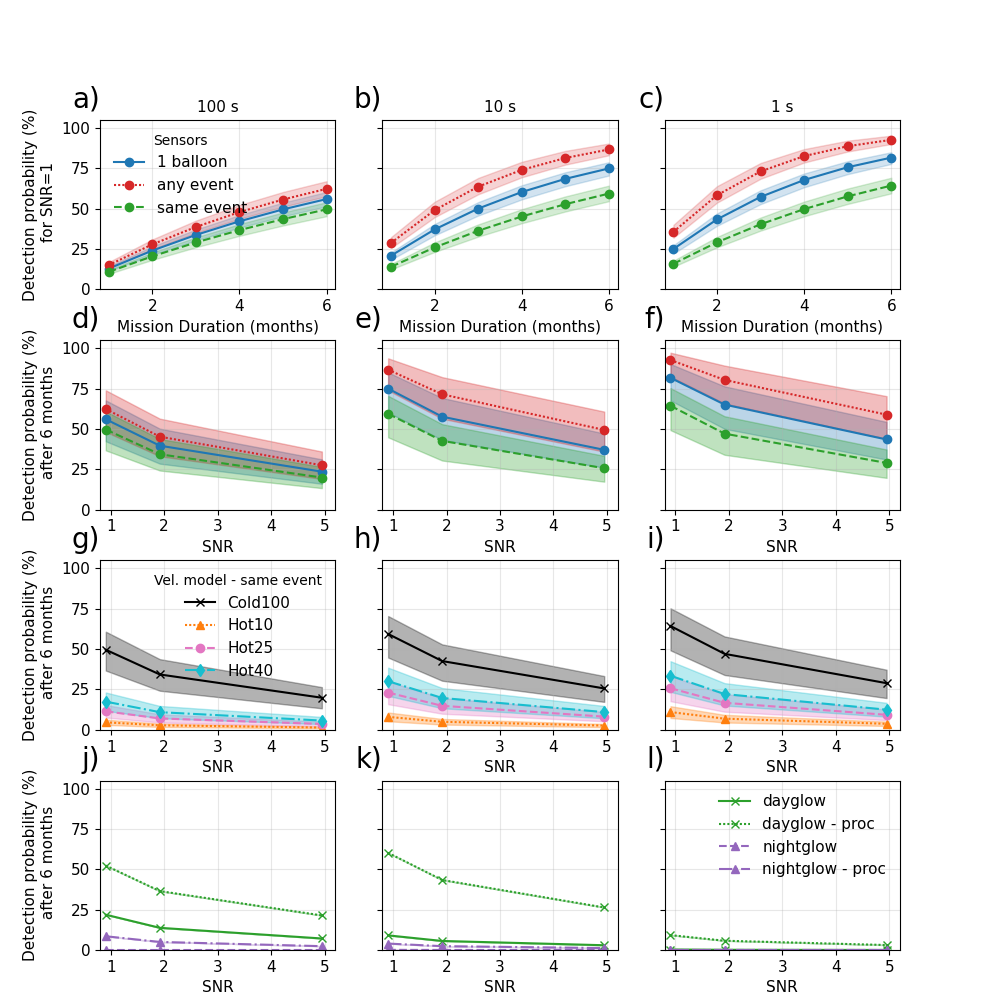

In [516]:
import string

def plot_proba_vs_duration(ax, alphabet, ifmax, fmax, pd_final_probas_fmax, snr_to_exclude, SNR_legend, seismicity_legend, fontsize_label, colors, ls, markers, color_labels, title_legend):
    
    snr_handles = []  # Handles for SNR legend
    seismicity_handles = []  # Handles for Seismicity legend

    for iseismicity, (seismicity, pd_final_probas_seismicity) in enumerate(pd_final_probas_fmax.groupby('seismicity')):

        for isnr, (snr, pd_final_probas_snr) in enumerate(pd_final_probas_seismicity.groupby('snr')):

            if snr in snr_to_exclude:
                continue

            duration = pd_final_probas_snr.duration.unique()
            probas = pd_final_probas_snr.groupby(['duration']).proba.median().reset_index().proba.values*1e2
            #qmin_probas = pd_final_probas_snr.groupby(['duration']).proba.min().reset_index().proba.values*1e2
            #qmax_probas = pd_final_probas_snr.groupby(['duration']).proba.max().reset_index().proba.values*1e2
            qmin_probas = pd_final_probas_snr.groupby(['duration']).proba.quantile(q=0.3).reset_index().proba.values*1e2
            qmax_probas = pd_final_probas_snr.groupby(['duration']).proba.quantile(q=0.7).reset_index().proba.values*1e2

            label_dict = dict()
            if iseismicity == 0 and ifmax == 0:
                snr_label = f'{snr:.0f}'
                label_dict = dict(label=snr_label)
                snr_handles.append(ax.plot([], [], marker=markers[iseismicity], color=colors[iseismicity], label=snr_label)[0])

            if ifmax == 0 and isnr == 0:
                seismicity_label = f'{seismicity}'
                seismicity_handles.append(ax.plot([], [], color=colors[iseismicity], marker=markers[iseismicity], label=seismicity_label, ls=ls[iseismicity])[0])

            ax.plot(duration/30., probas, marker=markers[iseismicity], color=colors[iseismicity], ls=ls[iseismicity], **label_dict)
            ax.fill_between(duration/30., qmin_probas, qmax_probas, color=colors[iseismicity], alpha=0.2)

    ax.tick_params(axis='both', colors=color_labels, labelsize=fontsize_label)
    if ifmax == 0 and SNR_legend:
        legend1 = ax.legend(handles=snr_handles, frameon=False, title='SNR', fontsize=fontsize_label, loc='upper right',)
        ax.add_artist(legend1)  # Add the first legend to the axis

    if ifmax == 0 and seismicity_legend:
        # Add the second legend for Seismicity
        ax.legend(handles=seismicity_handles, frameon=False,  title='Sensors', fontsize=fontsize_label, loc='upper left')
        #ax.legend(frameon=False, title='Seismicity', fontsize=fontsize_label, loc='upper right')

    if ifmax == 0:
        ax.set_ylabel('Detection probability (%)\n for SNR=1', color=color_labels, fontsize=fontsize_label)

    if ifmax > 0:
        ax.tick_params(axis='both', labelleft=False)

    ax.text(-0., 1.04, f'{alphabet[ifmax]})', fontsize=20., ha='right', va='bottom', transform=ax.transAxes)
    ax.set_xlabel('Mission Duration (months)', color=color_labels, fontsize=fontsize_label)
    ax.set_xlim([0.8, 6.2])
    ax.set_ylim([0, 100.])
    ax.set_title(f'{1./fmax:.0f} s', fontsize=fontsize_label, color=color_labels)
    ax.grid(alpha=0.3)

def plot_proba_vs_snr(ax, alphabet, ifmax, fmax, pd_final_probas_fmax, snr_to_exclude, SNR_legend, seismicity_legend, fontsize_label, colors, ls, markers, color_labels, title_legend, offset_alphabet, col_chosen='seismicity', ifmax_legend=0):
    
    snr_handles = []  # Handles for SNR legend
    seismicity_handles = []  # Handles for Seismicity legend

    for iseismicity, (seismicity, pd_final_probas_seismicity) in enumerate(pd_final_probas_fmax.groupby(col_chosen)):

        #for isnr, (snr, pd_final_probas_snr) in enumerate(pd_final_probas_seismicity.groupby('snr')):
        isnr = 0
        #snr = snr_selected
        duration_max = pd_final_probas_seismicity.duration.max()
        #print(f'{seismicity}: {duration_max/30}')
        pd_final_probas_snr = pd_final_probas_seismicity.loc[(pd_final_probas_seismicity.duration==duration_max)]
        snrs = pd_final_probas_snr.snr.unique()
        probas = pd_final_probas_snr.groupby(['snr']).proba.median().reset_index().proba.values*1e2
        #print(seismicity, probas)
        qmin_probas = pd_final_probas_snr.groupby(['snr']).proba.min().reset_index().proba.values*1e2
        qmax_probas = pd_final_probas_snr.groupby(['snr']).proba.max().reset_index().proba.values*1e2

        #if ifmax == 0 and isnr == 0:
        #    seismicity_label = f'{seismicity}'
        #    seismicity_handles.append(ax.plot([], [], '--', color='black', label=seismicity_label, ls=ls[iseismicity])[0])

        seismicity_label = dict()
        if ifmax == ifmax_legend:
            seismicity_label['label'] = f'{seismicity}'

        ax.plot(snrs, probas, marker=markers[iseismicity], color=colors[iseismicity], ls=ls[iseismicity], **seismicity_label)
        ax.fill_between(snrs, qmin_probas, qmax_probas, color=colors[iseismicity], alpha=0.3)

    ax.tick_params(axis='both', colors=color_labels, labelsize=fontsize_label)

    opt_title = dict() if title_legend is None else dict(title=title_legend,)
    if ifmax == ifmax_legend and seismicity_legend:    
        ax.legend(frameon=False, **opt_title, fontsize=fontsize_label, loc='upper right', ncol=1)
    #if ifmax == 0 and seismicity_legend:
    #    ax.legend(frameon=False, title='Network', fontsize=fontsize_label, loc='upper left')

    if ifmax == 0:
        ax.set_ylabel(f'Detection probability (%)\n after {duration_max/30:g} months', color=color_labels, fontsize=fontsize_label)

    if ifmax > 0:
        ax.tick_params(axis='both', labelleft=False)

    ax.text(-0., 1.04, f'{alphabet[ifmax+offset_alphabet]})', fontsize=20., ha='right', va='bottom', transform=ax.transAxes)
    ax.set_xlabel('SNR', color=color_labels, fontsize=fontsize_label)
    ax.set_xlim([0.8, 5.2])
    ax.set_ylim([0, 100.])
    #ax.set_title(f'{1./fmax:.0f} s', fontsize=fontsize_label, color=color_labels)
    ax.grid(alpha=0.3)


def plot_proba_statistics_no_distrib(pd_final_probas, pd_final_probas_airglow, vel_model_highlight, show_balloon_w_airglow=False, color_labels='black', fontsize_label=11., file=None, SNR_legend=True, seismicity_legend=False, snr_to_exclude=[], ylim=[0., 105]):

    alphabet = string.ascii_lowercase
    colors = ['tab:blue', 'tab:red', 'tab:green']
    ls = ['-', (0, (1, 1)), '--']
    markers = ['o', 'o', 'o']
    fmaxs = pd_final_probas.fmax.unique()
    title_legend = 'Sensors'

    fig = plt.figure(figsize=(3*fmaxs.size+1,10))
    grid = fig.add_gridspec(4, fmaxs.size)
    
    for ifmax, (fmax, pd_final_probas_fmax_global) in enumerate(pd_final_probas.groupby('fmax')):

        pd_final_probas_fmax = pd_final_probas_fmax_global.loc[pd_final_probas_fmax_global.vel_model==vel_model_highlight]
        
        ## duration vs proba
        ax = fig.add_subplot(grid[0, ifmax])
        rect = plt.Rectangle(
            (0, 0), 1, 1,
            transform=ax.transAxes,  # Use axes coordinates
            color='white',
            zorder=-1,  # Place it below all other elements
        )
        ax.add_patch(rect)
        
        plot_proba_vs_duration(ax, alphabet, ifmax, fmax, pd_final_probas_fmax, snr_to_exclude, False, True, fontsize_label, colors, ls, markers, color_labels, title_legend)
        ax.set_ylim(ylim)
        
        ## SNR vs proba
        ax = fig.add_subplot(grid[1, ifmax])
        rect = plt.Rectangle(
            (0, 0), 1, 1,
            transform=ax.transAxes,  # Use axes coordinates
            color='white',
            zorder=-1,  # Place it below all other elements
        )
        ax.add_patch(rect)
        plot_proba_vs_snr(ax, alphabet, ifmax, fmax, pd_final_probas_fmax, snr_to_exclude, False, False, fontsize_label, colors, ls, markers, color_labels, title_legend, 3)
        ax.set_ylim(ylim)
        
    markers = ['x', '^', 'o', 'd']
    colors = ['black', 'tab:orange', 'tab:pink', 'tab:cyan']
    ls = ['-', (0, (1, 1)), '--', '-.']
    title_legend = 'Vel. model - same event'
    for ifmax, (fmax, pd_final_probas_fmax) in enumerate(pd_final_probas.loc[pd_final_probas.seismicity=='same event'].groupby('fmax')):
        
        ## SNR vs proba
        ax = fig.add_subplot(grid[2, ifmax])
        rect = plt.Rectangle(
            (0, 0), 1, 1,
            transform=ax.transAxes,  # Use axes coordinates
            color='white',
            zorder=-1,  # Place it below all other elements
        )
        ax.add_patch(rect)
        #plot_proba_vs_snr_vel(ax, alphabet, ifmax, fmax, pd_final_probas_fmax, snr_to_exclude, False, True, fontsize_label, colors, ls, markers, color_labels, title_legend, 9)
        plot_proba_vs_snr(ax, alphabet, ifmax, fmax, pd_final_probas_fmax, snr_to_exclude, False, True, fontsize_label, colors, ls, markers, color_labels, title_legend, 6, col_chosen='vel_model')
        ax.set_ylim(ylim)
        
    markers = ['x', 'x', '^', '^']
    colors = ['tab:green', 'tab:green', 'tab:purple','tab:purple', ]
    title_legend = 'Sensors - same event'
    title_legend = None
    for ifmax, (fmax, pd_final_probas_fmax) in enumerate(pd_final_probas_airglow.groupby('fmax')):
        
        ## SNR vs proba
        ax = fig.add_subplot(grid[3, ifmax])
        rect = plt.Rectangle(
            (0, 0), 1, 1,
            transform=ax.transAxes,  # Use axes coordinates
            color='white',
            zorder=-1,  # Place it below all other elements
        )
        ax.add_patch(rect)
        plot_proba_vs_snr(ax, alphabet, ifmax, fmax, pd_final_probas_fmax, snr_to_exclude, False, True, fontsize_label, colors, ls, markers, color_labels, title_legend, 9, ifmax_legend=2)
        ax.set_ylim(ylim)
        
    
        
    fig.subplots_adjust(left=0.1, bottom=0.05, hspace=0.3)
        
    if file is not None:
        fig.savefig(file, transparent=True)

snr_available = pd_final_probas.snr.unique()
snr_to_exclude = [snr_available[np.argmin(abs(snr_available-snr))] for snr in [2, 5]]
#file = f'/staff/quentin/Documents/Projects/2024_Venus_Detectability/figures/Figure_4_statistics_sensors_velmodel_20.12.2025_24months.pdf'
file = f'/staff/quentin/Documents/Projects/2024_Venus_Detectability/figures/Figure_4_statistics_sensors_velmodel_20.12.2025.pdf'
#file = None
plot_proba_statistics_no_distrib(pd_final_probas, pd_final_probas_airglow, vel_model_highlight, color_labels='black', file=file, SNR_legend=True, seismicity_legend=True, snr_to_exclude=snr_to_exclude)